In [5]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph.message import add_messages
from typing import Optional, TypedDict, Annotated

C:\Users\ankit\AppData\Local\Temp\ipykernel_7960\1610577545.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [9]:
load_dotenv()

True

In [10]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [11]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2-preview", 
    output_dimensionality=768
)

In [12]:
docs= (PyPDFLoader("./research-paper/doc.pdf").load())

In [ ]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size= 1000, chunk_overlap=200).split_documents(docs)

In [14]:
vectorstore = FAISS.from_documents(chunks, embeddings)

GoogleGenerativeAIError: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 100, model: gemini-embedding-2\nPlease retry in 32.906564559s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/embed_content_free_tier_requests', 'quotaId': 'EmbedContentRequestsPerMinutePerUserPerProjectPerModel-FreeTier', 'q

In [15]:
vectorstore

NameError: name 'vectorstore' is not defined

In [28]:
class State(TypedDict):
    query: str
    needs_retrieval: Annotated[bool, "Whether the query needs retrieval or not."]

    docs: list[Document]

    answer: str
    context: str

In [29]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

NameError: name 'vectorstore' is not defined

In [30]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

class RetrieveDecision(BaseModel):
    needs_retrieval: bool = Field(..., description="Whether the query needs retrieval or not.")

retrieval_decision_prompt = """You decide whether the query needs retrieval or not. 
If the query is related to the research paper, you should set needs_retrieval to True, Something
not in parametric Knowledge of LLM, and only present in the Research Paper. 
Otherwise, set it to False.
"""

retrieval_decider = llm.with_structured_output(RetrieveDecision)
def retrieval_decision_node(state:State):
    response = retrieval_decider.invoke([SystemMessage(content=retrieval_decision_prompt), HumanMessage(content=state["query"])])
    return {"needs_retrieval": response.needs_retrieval}


In [31]:
direct_answer_prompt = ChatPromptTemplate.from_messages([
    ("system" , 
     """
Answer the question based on your parametric knowledge. If you don't know the answer, say "I don't know".
Do NOT assume access to external sources or the research paper. Only use your own knowledge to answer the question.
"""),
("human" , "{query}")])

In [33]:
def direct_answer_node(state:State):
    prompt = direct_answer_prompt.format_prompt(query=state["query"])
    response = llm.invoke(prompt)
    return {"answer": response.content, "context": ""}

In [34]:
def retrieval_node(state:State):
    docs = retriever.invoke(state["query"])
    return {"docs": docs}

In [35]:
def route_after_retrieval_decision(state:State):
    if state["needs_retrieval"]:
        return "retrieval_node"
    else:
        return "direct_answer_node"

In [36]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(..., description="True if the document helps answer the question, else False")

In [37]:
RELEVANCE_DECISION_PROMPT = """You are given a question and a document. You need to decide whether the document is relevant to the question or not.
If the document helps answer the question, set is_relevant to True. Otherwise, set it
to False.
"""

In [38]:
def relevance_decision_node(state:State):
    query = state["query"]
    docs = state["docs"]
    relevance_decider = llm.with_structured_output(RelevanceDecision)
    relevant_docs : list[Document] = []
    for doc in docs:
        prompt = ChatPromptTemplate.from_messages([
            ("system", RELEVANCE_DECISION_PROMPT),
            ("human", f"Question: {query}\nDocument: {doc.page_content}")
        ]).format_prompt()
        
        response = relevance_decider.invoke(prompt)
        if response.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

In [ ]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
        """
You are a Research RAG Assistant. You are given a question and a set of documents. You need to answer the question based on the documents.
If the documents do not contain enough information to answer the question, say "I don't know".
Do NOT use your parametric knowledge to answer the question. Only use the documents to answer the question.
"""),
    ("human", "{query}"),
    ("human", "Documents: {context}")
])

In [39]:
def generate_from_rag(state:State):
    context= [doc.page_content for doc in state["relevant_docs"]].join("\n\n")
    if not context:
        return {"answer": "I don't know", "context": ""}
    prompt = RAG_PROMPT.format_prompt(query=state["query"], context=context)
    response = llm.invoke(prompt)
    return {"answer": response.content, "context": context}

In [40]:
def no_relevant_docs_node(state:State):
    return {"answer": "I don't know", "context": ""}

In [41]:
def route_after_relevance_decision(state:State):
    if state["relevant_docs"] and len(state["relevant_docs"]) > 0:
        return "generate_from_rag"
    else:
        return "no_relevant_docs_node"

In [42]:
g = StateGraph(State)
#add nodes
g.add_node("retrieval_decision_node", retrieval_decision_node)
g.add_node("retrieval_node", retrieval_node)
g.add_node("relevance_decision_node", relevance_decision_node)
g.add_node("generate_from_rag", generate_from_rag)
g.add_node("no_relevant_docs_node", no_relevant_docs_node)
g.add_node("direct_answer_node", direct_answer_node)

In [43]:
#add edges
g.add_edge(START, "retrieval_decision_node")
g.add_conditional_edges("retrieval_decision_node", route_after_retrieval_decision)
g.add_edge("direct_answer_node", END)
g.add_edge("retrieval_node", 'relevance_decision_node')
g.add_conditional_edges("relevance_decision_node", route_after_relevance_decision)
g.add_edge("generate_from_rag", END)
g.add_edge("no_relevant_docs_node", END)

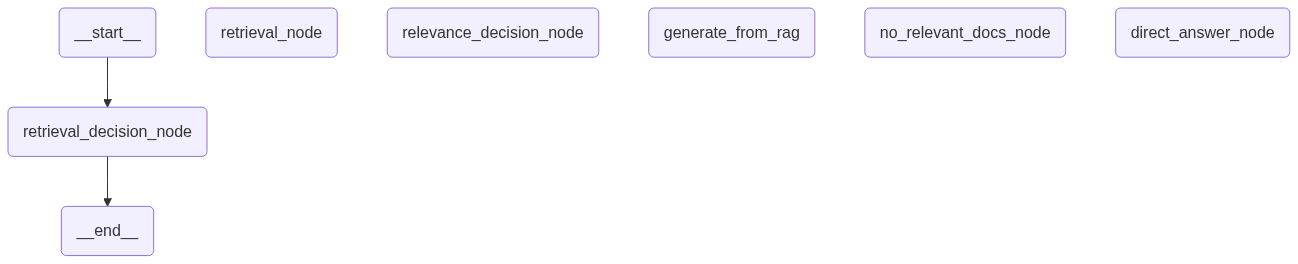

In [44]:
workflow = g.compile()
workflow

In [45]:
query = "What is full form of AI"
response = workflow.invoke({"query": query})
response

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'query': 'What is full form of AI',
 'needs_retrieval': False,
 'answer': [{'type': 'text',
   'text': 'The full form of AI is **Artificial Intelligence**.',
   'extras': {'signature': 'EmAKXgFpFH0TOAUVCC5ZS+sPt3PuYpP3gaaoKT3JYig5cR19D42+92joEjWicJUn5XuCcQNMT7lRqzBBvAN/4rDbDigEzBPar3K3Qm3urd/wUjwtI3lDxj7Y3pZTzX05upY='}}],
 'context': ''}

In [52]:
query = "What is the main contribution of the research paper?"
response = workflow.invoke({"query": query})
response

NameError: name 'retriever' is not defined

In [1]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(..., description="True if the document helps answer the question, else False")

NameError: name 'BaseModel' is not defined